数据前5行:


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0



数据基本信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB
None

缺失值统计:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


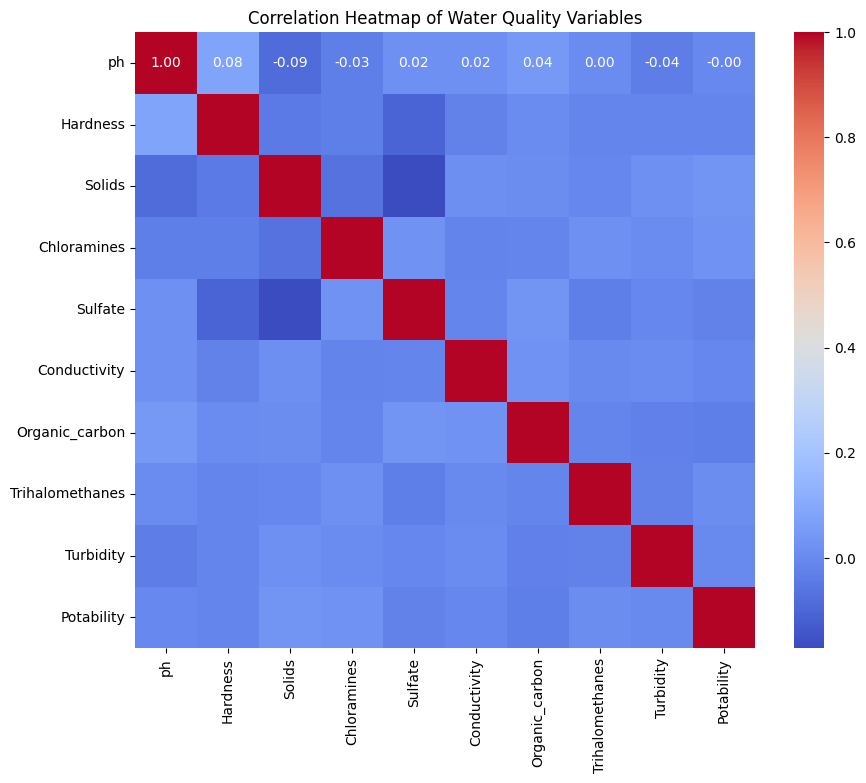

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 加载数据 (注意这里路径的更改)
# 假设你的文件名为 water_potability.csv，它放在当前目录下的 data 文件夹中
file_path = 'data/water_potability.csv' 
df = pd.read_csv(file_path)

# 2. 查看数据的前5行和基本信息
print("数据前5行:")
display(df.head())

print("\n数据基本信息:")
print(df.info())

# 3. 查看缺失值情况
print("\n缺失值统计:")
print(df.isnull().sum())

# 4. 探索多元变量数据之间的相关性
plt.figure(figsize=(10, 8))
# 计算特征之间的相关系数并画出热力图
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Water Quality Variables")
plt.show()

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 1. 分离特征 (X) 和 目标标签 (y)
X = df.drop('Potability', axis=1) # 特征：所有的水质指标
y = df['Potability']              # 目标：是否可饮用 (0 或 1)



# 2. 划分训练集和测试集 (80%用于训练模型，20%用于像考试一样测试模型)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 处理缺失值：这里我们用每一列的"均值"来填补缺失的传感器数据
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test) # 注意：测试集只能用 transform

# 4. 特征标准化 (Z-score 归一化)，让所有特征处于同一个起跑线
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("数据预处理完成！")

数据预处理完成！


In [3]:
print(X_train_scaled[:3]) # 查看前3行处理后的数据

[[-0.31822108  0.20204646 -0.55463361 -0.66652723 -0.60582139 -0.19929648
   0.50622105 -0.08418885 -1.3411035 ]
 [-0.27644949 -0.08006604  1.36873646  1.74381264  0.30066166  0.88258563
  -1.65420736  0.01920078  0.09082874]
 [-0.17294725  0.28302115 -0.42399002 -0.24879087 -0.9895633   0.83848598
  -0.13486017  0.27512281  1.27418303]]


--- 逻辑回归模型 ---
逻辑回归 预测准确率 (Accuracy): 0.6280

--- K-近邻模型 (KNN) ---
KNN 预测准确率 (Accuracy): 0.6280


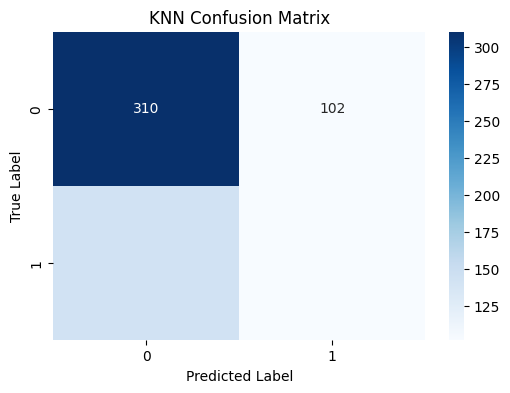

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==========================================
# 1. 训练逻辑回归模型 (Logistic Regression)
# ==========================================
print("--- 逻辑回归模型 ---")
# 初始化模型
log_reg = LogisticRegression(random_state=42)
# 让模型在训练集上学习 (fit)
log_reg.fit(X_train_scaled, y_train)
# 让学好的模型在测试集上进行预测 (predict)
y_pred_log = log_reg.predict(X_test_scaled)

# 评估成绩
acc_log = accuracy_score(y_test, y_pred_log)
print(f"逻辑回归 预测准确率 (Accuracy): {acc_log:.4f}")

# ==========================================
# 2. 训练 K-近邻模型 (KNN)
# ==========================================
print("\n--- K-近邻模型 (KNN) ---")
# 初始化模型 (设置寻找最近的 5 个邻居)
knn = KNeighborsClassifier(n_neighbors=5)
# 让模型在训练集上学习
knn.fit(X_train_scaled, y_train)
# 进行预测
y_pred_knn = knn.predict(X_test_scaled)

# 评估成绩
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"KNN 预测准确率 (Accuracy): {acc_knn:.4f}")

# ==========================================
# 3. 绘制 KNN 的混淆矩阵 (Confusion Matrix)
# ==========================================
# 混淆矩阵能帮我们直观看到模型把多少“不可饮用”错判成了“可饮用”，反之亦然
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [5]:
from sklearn.metrics import classification_report

print("--- 逻辑回归 详细体检报告 ---")
print(classification_report(y_test, y_pred_log))

--- 逻辑回归 详细体检报告 ---
              precision    recall  f1-score   support

           0       0.63      1.00      0.77       412
           1       0.00      0.00      0.00       244

    accuracy                           0.63       656
   macro avg       0.31      0.50      0.39       656
weighted avg       0.39      0.63      0.48       656



D:\ANACONDA\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\ANACONDA\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\ANACONDA\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
